In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heart+disease.zip to heart+disease.zip


In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv('heart.csv')

print(df.head())
print(df.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'heart.csv'

In [ ]:
import os

print(os.listdir())

['.config', 'heart+disease.zip', 'sample_data']


In [ ]:
!unzip "heart+disease.zip"

Archive:  heart+disease.zip
  inflating: Index                   
  inflating: WARNING                 
  inflating: ask-detrano             
  inflating: bak                     
  inflating: cleve.mod               
  inflating: cleveland.data          
   creating: costs/
  inflating: costs/Index             
  inflating: costs/heart-disease.README  
  inflating: costs/heart-disease.cost  
  inflating: costs/heart-disease.delay  
  inflating: costs/heart-disease.expense  
  inflating: costs/heart-disease.group  
  inflating: heart-disease.names     
  inflating: hungarian.data          
  inflating: long-beach-va.data      
  inflating: new.data                
  inflating: processed.cleveland.data  
  inflating: processed.hungarian.data  
  inflating: processed.switzerland.data  
  inflating: processed.va.data       
  inflating: reprocessed.hungarian.data  
  inflating: switzerland.data        


In [ ]:
import os
print(os.listdir())

['.config', 'hungarian.data', 'ask-detrano', 'new.data', 'processed.va.data', 'cleveland.data', 'reprocessed.hungarian.data', 'heart+disease.zip', 'WARNING', 'heart-disease.names', 'switzerland.data', 'processed.hungarian.data', 'processed.cleveland.data', 'Index', 'cleve.mod', 'costs', 'long-beach-va.data', 'bak', 'processed.switzerland.data', 'sample_data']


In [ ]:
import pandas as pd

column_names = [
    'age','sex','cp','trestbps','chol','fbs',
    'restecg','thalach','exang','oldpeak',
    'slope','ca','thal','target'
]

df = pd.read_csv(
    'processed.cleveland.data',
    names=column_names
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
print(df.shape)
print(df.info())
print(df.head())

(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB
None
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.

In [ ]:
df.replace('?', pd.NA, inplace=True)

df = df.dropna()

print(df.shape)

(297, 14)


In [ ]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col])

In [ ]:
0 = No Heart Disease
1,2,3,4 = Heart Disease

SyntaxError: cannot assign to literal here. Maybe you meant '==' instead of '='? (24367031.py, line 1)

In [ ]:
0 == No Heart Disease
1,2,3,4 == Heart Disease

SyntaxError: invalid syntax (3532550696.py, line 1)

In [ ]:
df['target'] = (df['target'] > 0).astype(int)

df['target'].value_counts()

,count
target,
0,160
1,137


In [ ]:
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(df.shape)
print(df.head())
print(df['target'].value_counts())

(297, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  
target
0    160
1    137
Name: count, dtype: int64


In [ ]:
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8666666666666667


In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.8833333333333333


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8833333333333333


In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.8166666666666667


In [ ]:
results = {
    'Logistic Regression': lr_acc,
    'SVM': svm_acc,
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc
}

for model, acc in results.items():
    print(f"{model}: {acc*100:.2f}%")

Logistic Regression: 86.67%
SVM: 88.33%
Random Forest: 88.33%
XGBoost: 81.67%


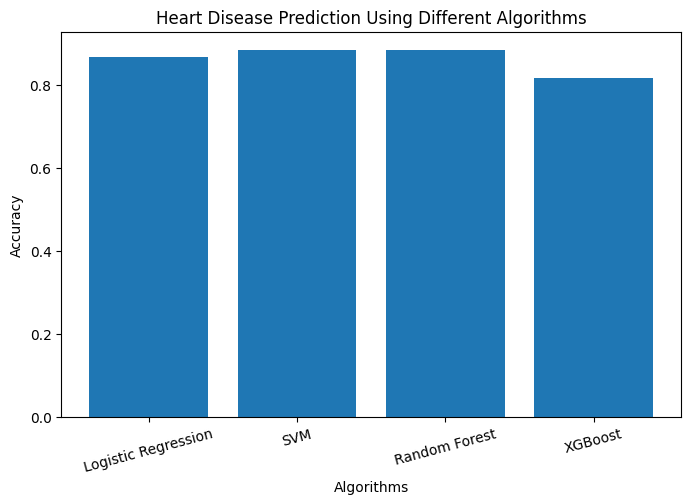

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.xlabel("Algorithms")
plt.title("Heart Disease Prediction Using Different Algorithms")
plt.xticks(rotation=15)
plt.show()

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss'
)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.8666666666666667


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

svm = SVC()

scores = cross_val_score(svm, X_train_scaled, y_train, cv=5)

print("CV Accuracy:", scores.mean())

CV Accuracy: 0.8145390070921987


In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
lr_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_train_scaled,
    y_train,
    cv=5
)

print("LR CV Accuracy:", lr_scores.mean())

LR CV Accuracy: 0.822695035460993


In [ ]:
svm_scores = cross_val_score(
    SVC(),
    X_train_scaled,
    y_train,
    cv=5
)

print("SVM CV Accuracy:", svm_scores.mean())

SVM CV Accuracy: 0.8145390070921987


In [ ]:
rf_scores = cross_val_score(
    RandomForestClassifier(random_state=42),
    X_train,
    y_train,
    cv=5
)

print("RF CV Accuracy:", rf_scores.mean())

RF CV Accuracy: 0.8016843971631206


In [ ]:
xgb_scores = cross_val_score(
    XGBClassifier(eval_metric='logloss'),
    X_train,
    y_train,
    cv=5
)

print("XGB CV Accuracy:", xgb_scores.mean())

XGB CV Accuracy: 0.7805851063829786


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_

feature_imp = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

feature_imp.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_

feature_imp = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

print(feature_imp)

thalach     0.128595
ca          0.128311
thal        0.104479
oldpeak     0.103659
cp          0.103653
chol        0.097724
age         0.094957
trestbps    0.089756
exang       0.052210
slope       0.033971
sex         0.032460
restecg     0.016737
fbs         0.013488
dtype: float64


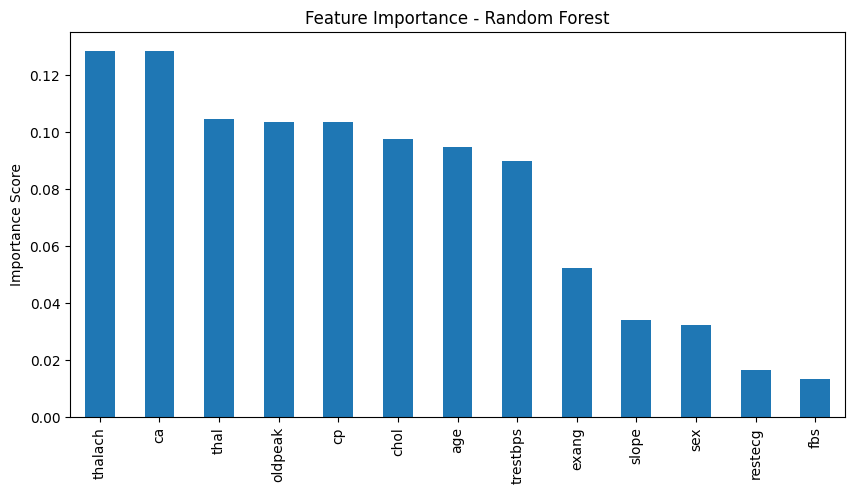

In [ ]:
feature_imp.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
for model, acc in results.items():
    print(f"{model}: {acc*100:.2f}%")

Logistic Regression: 86.67%
SVM: 88.33%
Random Forest: 88.33%
XGBoost: 81.67%


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.8666666666666667


In [ ]:
results = {
    'Logistic Regression': lr_acc,
    'SVM': svm_acc,
    'Random Forest': rf_acc,
    'XGBoost': xgb_acc
}

for model, acc in results.items():
    print(f"{model}: {acc*100:.2f}%")

Logistic Regression: 86.67%
SVM: 88.33%
Random Forest: 88.33%
XGBoost: 86.67%


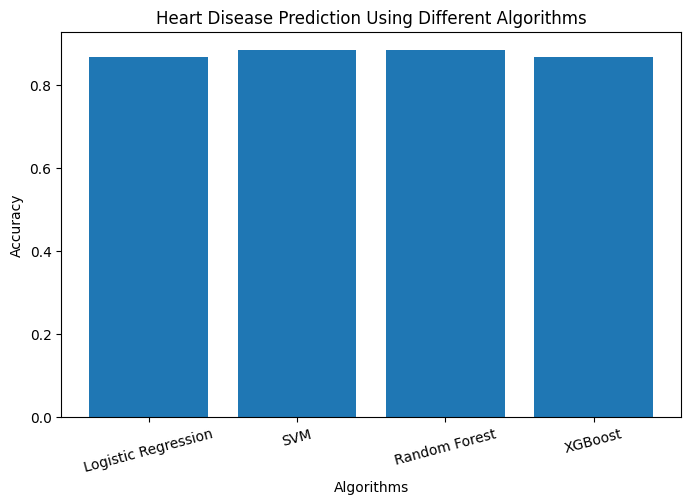

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())

plt.ylabel("Accuracy")
plt.xlabel("Algorithms")
plt.title("Heart Disease Prediction Using Different Algorithms")

plt.xticks(rotation=15)
plt.show()

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    'Algorithm': ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost'],
    'Accuracy (%)': [
        lr_acc*100,
        svm_acc*100,
        rf_acc*100,
        xgb_acc*100
    ]
})

print(results_df)

             Algorithm  Accuracy (%)
0  Logistic Regression     86.666667
1                  SVM     88.333333
2        Random Forest     88.333333
3              XGBoost     86.666667


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion

SyntaxError: unterminated string literal (detected at line 9) (3331058265.py, line 9)

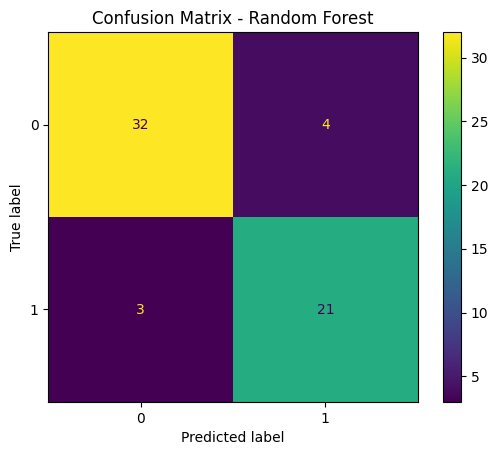

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90        36
           1       0.84      0.88      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best Score: 0.7932624113475178


In [ ]:
best_xgb = grid.best_estimator_

pred = best_xgb.predict(X_test)

from sklearn.metrics import accuracy_score
print("Test Accuracy:", accuracy_score(y_test, pred))

Test Accuracy: 0.85


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    random_state=42
)